<a href="https://colab.research.google.com/github/mariusz1234567890/python-intro/blob/main/regresja_liniowa_%7C_wst%C4%99p_do_Ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wczytanie zbioru danych:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. cen

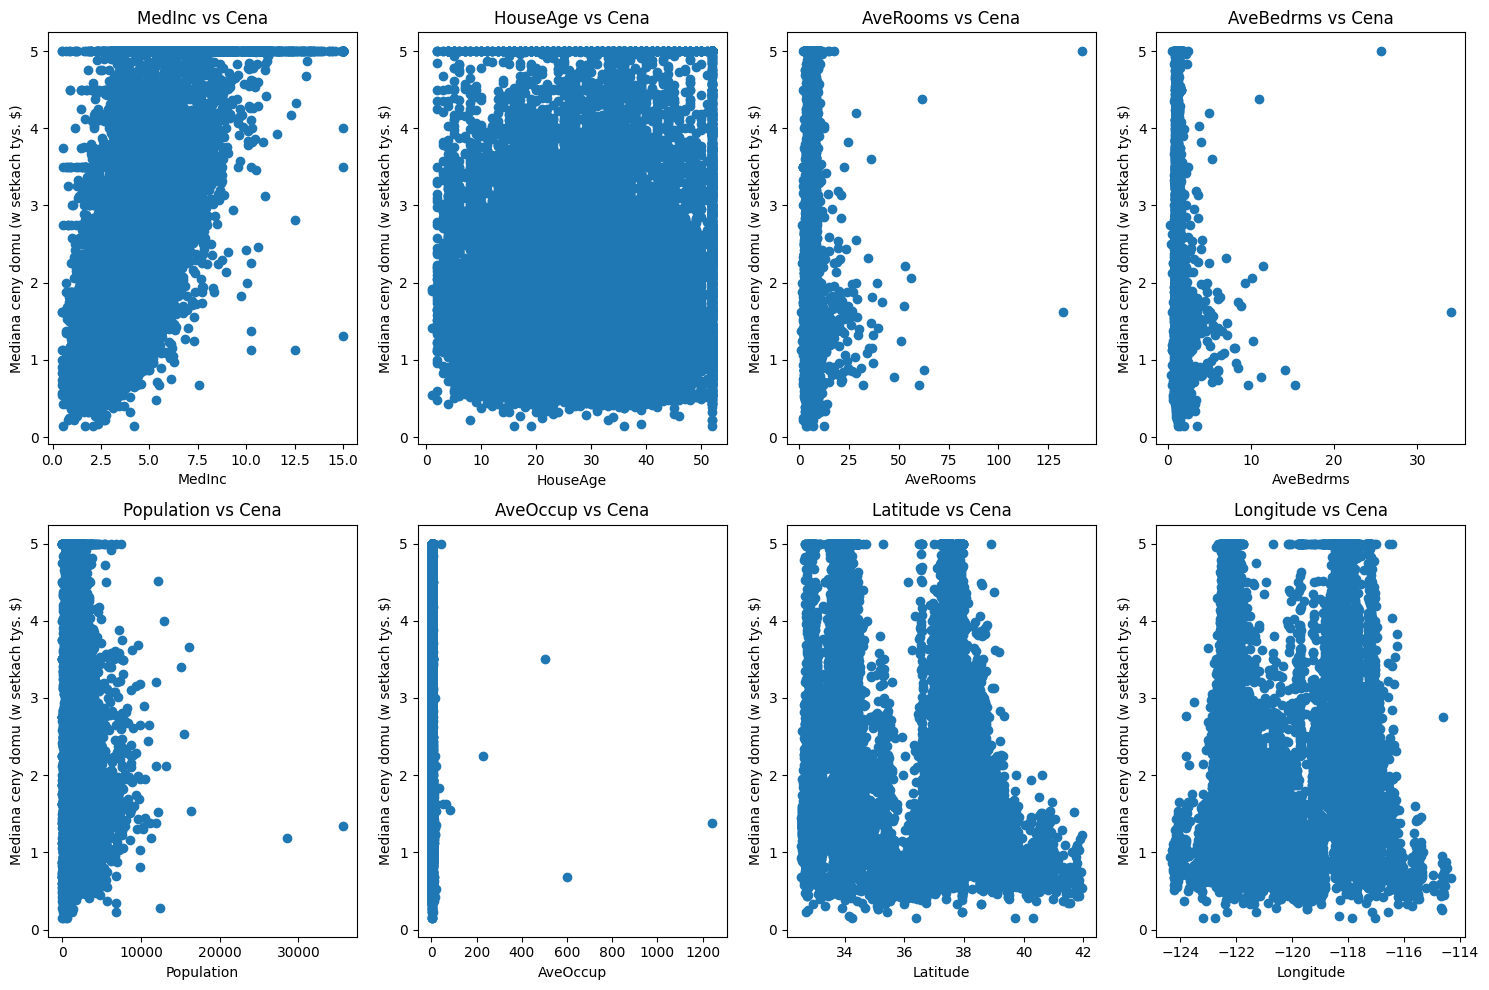

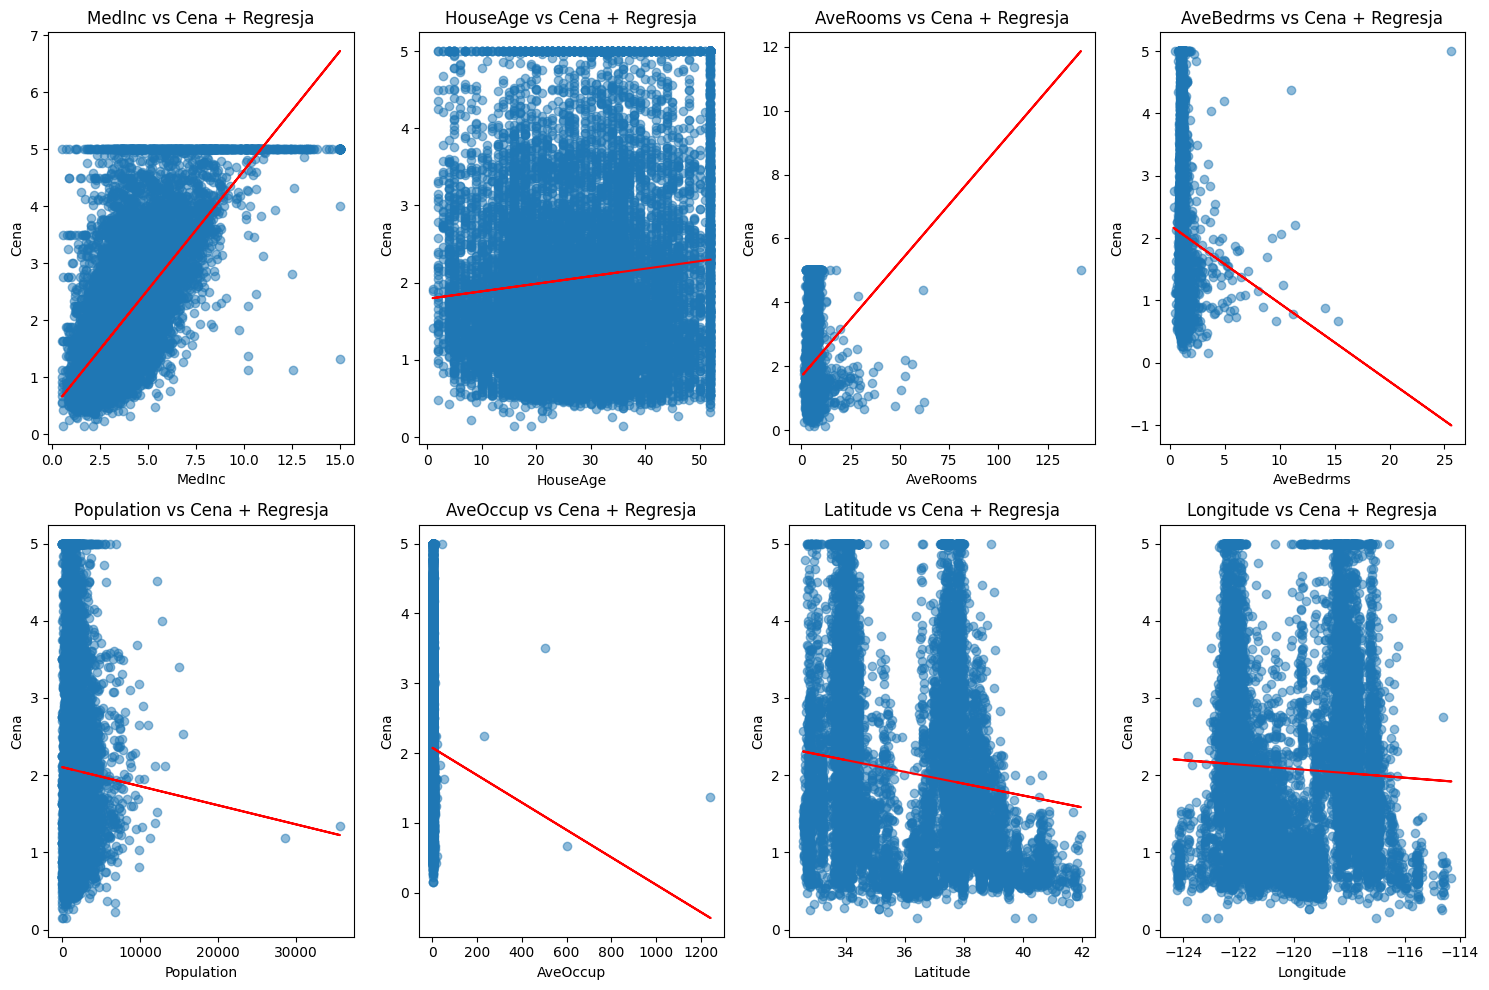

Analiza wyników Porównaj błędy z (e) i (f): Pełny model (wszystkie 8 cech): MAE~0.53, MSE~0.52 – niższe błędy. Pojedyncze cechy: Wyższe błędy (MAE 0.7-1.0+, MSE 0.9-1.3+), bo jedna cecha wyjaśnia mniej wariancji. Wniosek: Uczenie na pojedynczych zwiększa błąd – model potrzebuje wszystkich cech dla lepszej predykcji. Najlepsza pojedyncza: MedInc (najniższy błąd), najgorsza: Longitude/Latitude (słaba korelacja liniowa)


In [26]:


import pandas as pd
from sklearn.datasets import fetch_california_housing


'''Wczytanie zbióru danych'''
print("Wczytanie zbioru danych:")

# Wczytaj dane
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Wyświetl opis i próbki (do sprawdzenia)
print(data.DESCR)  # Opis zbioru
print(X.head())    # Pierwsze 5 wierszy X
print(y.head())    # Pierwsze 5 wartości y
print(X.shape)     # (20640, 8)

'''Wykonanie 8 wykresów: y vs każdej xi'''
print("Wykonanie 8 wykresów: y vs każdej xi:")
import matplotlib.pyplot as plt

# Dla inline wykresów w Colab
%matplotlib inline


# Lista nazw cech
features = data.feature_names

# 8 wykresów w siatce 2x4
fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    axes[i].scatter(X[feature], y)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Mediana ceny domu (w setkach tys. $)')
    axes[i].set_title(f'{feature} vs Cena')

plt.tight_layout()
plt.savefig('wykresy_cech.png')
# Wykresy pokażą się automatycznie poniżej komórki

'''Podzielenie dane na uczący (70%) i testujący (30%)'''
print("Podzielenie danych na uczący i testujący:")
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape)  # Powinno być ok. (14448, 8)
print(X_test.shape)   # (6192, 8)


''' Naucz model LinearRegression na danych uczących'''
print("Naucz model LinearRegression na danych uczących:")

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Wyświetl współczynniki
print("Współczynniki (wagi):", model.coef_)
print("Bias (intercept):", model.intercept_)


''' Oblicznie MAE i MSE na train i test, ocena modelu'''
print("MAE i MSE na train i test:")
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predykcje
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Błędy
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"Train MAE: {mae_train:.4f}, MSE: {mse_train:.4f}")
print(f"Test MAE: {mae_test:.4f}, MSE: {mse_test:.4f}")

# Ocena
model.score(X_test, y_test)


'''Dla każdej z 8 zmiennych: model na pojedynczej, wykres z linią, MAE/MSE'''
print("Dla każdej z 8 zmiennych:")
fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    # Wybierz jedną kolumnę
    X_train_single = X_train[[feature]]
    X_test_single = X_test[[feature]]

    # Naucz model
    model_single = LinearRegression()
    model_single.fit(X_train_single, y_train)

    # Predykcje do wykresu
    y_pred_single = model_single.predict(X_train_single)

    # Wykres: scatter + linia regresji
    axes[i].scatter(X_train[feature], y_train, alpha=0.5)
    axes[i].plot(X_train[feature], y_pred_single, color='red')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Cena')
    axes[i].set_title(f'{feature} vs Cena + Regresja')

    # Błędy na test
    y_test_pred_single = model_single.predict(X_test_single)
    mae_single = mean_absolute_error(y_test, y_test_pred_single)
    mse_single = mean_squared_error(y_test, y_test_pred_single)
    print(f"{feature}: Test MAE: {mae_single:.4f}, MSE: {mse_single:.4f}")

plt.tight_layout()
plt.show()

'''wnioski'''
print("Analiza wyników Porównaj błędy z (e) i (f): Pełny model (wszystkie 8 cech): MAE~0.53, MSE~0.52 – niższe błędy. Pojedyncze cechy: Wyższe błędy (MAE 0.7-1.0+, MSE 0.9-1.3+), bo jedna cecha wyjaśnia mniej wariancji. Wniosek: Uczenie na pojedynczych zwiększa błąd – model potrzebuje wszystkich cech dla lepszej predykcji. Najlepsza pojedyncza: MedInc (najniższy błąd), najgorsza: Longitude/Latitude (słaba korelacja liniowa)")